# E-Commerce Customer Analytics
## Univariate Analysis

This notebook explores the distributions of key customer, transaction, engagement, and churn variables across four e-commerce datasets. The analysis uses the cleaned EDA datasets prepared in `01_data_preparation.ipynb`.

The focus is on distribution shape, category balance, potential outliers, and selected group comparisons that help identify variables worth carrying forward into later analysis.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

DATA_DIR = Path("../data")


## 1. User Behavior & Engagement

This dataset combines customer demographics, order information, sales outcomes, and online engagement behavior.


### 1.1 Load Data


In [2]:
df_behavior = pd.read_pickle(DATA_DIR / "df_behavior_eda.pkl")
df_behavior.shape


(51207, 27)

### 1.2 Analysis Variables

Identifier and date fields are excluded from the main distribution plots. Numeric, categorical, and binary engagement variables are handled separately based on their measurement type.


In [ ]:
numeric_cols_behavior = ["Age", "Sales", "Quantity", "Discount","Profit", "Shipping Cost", "Browsing Time (min)"]

categorical_cols_behavior = ["Segment", "Region", "Gender", "Education","Marital Status", "Ship Mode", "Product Category","Order Priority"]

binary_cols_behavior = ["Like", "Share", "Add to Cart"]


### 1.3 Summary Statistics


In [ ]:
summary_stats_behavior = (df_behavior[numeric_cols_behavior].agg(["mean", "median", lambda x: x.mode().iloc[0], "min", "max"]).T.rename(columns={"<lambda>": "mode"}))

summary_stats_behavior


,mean,median,mode,min,max
Age,31.308005,28.00,18.00,18.00,70.00
Sales,156.421310,159.00,228.00,33.00,250.00
Quantity,2.997481,3.00,3.00,1.00,5.00
Discount,0.029971,0.03,0.03,0.01,0.05
Profit,72.718962,67.00,17.00,0.50,167.50
Shipping Cost,7.272457,6.70,2.10,0.10,16.80
Browsing Time (min),17.283073,16.50,7.40,1.00,40.00


Age is concentrated toward younger customers, while `Sales`, `Profit`, `Shipping Cost`, and `Browsing Time (min)` span wider ranges. `Quantity` and `Discount` take only a small number of distinct values, so count plots are more informative for those variables.


### 1.4 Numeric Distributions


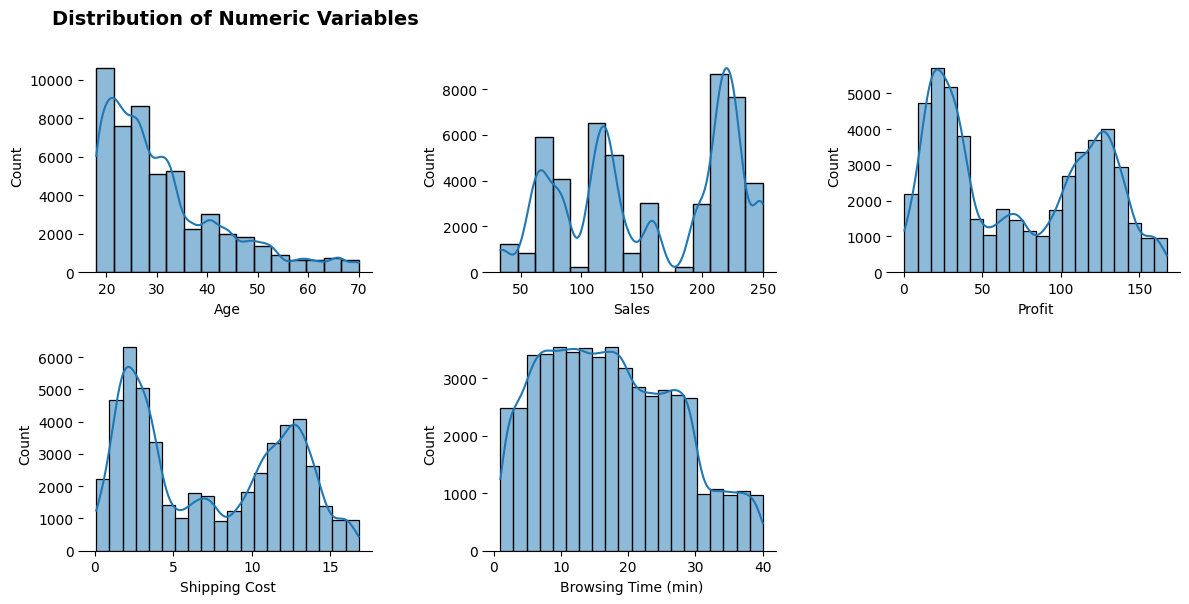

In [5]:
# Histograms for selected numeric variables
bin_settings = {"Age": 15,"Sales": 15,"Profit": 20,"Shipping Cost": 20,"Browsing Time (min)": 20}
cols = 3
plot_cols = list(bin_settings.keys())
rows = (len(plot_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    sns.histplot(data=df_behavior, x=col, bins=bin_settings[col], kde=True, ax=axes[i])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)
# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Numeric Variables", fontsize=14, fontweight="bold", y=1, x=0.2)
plt.tight_layout()
plt.subplots_adjust(wspace=0.4, hspace=0.3)
plt.show()

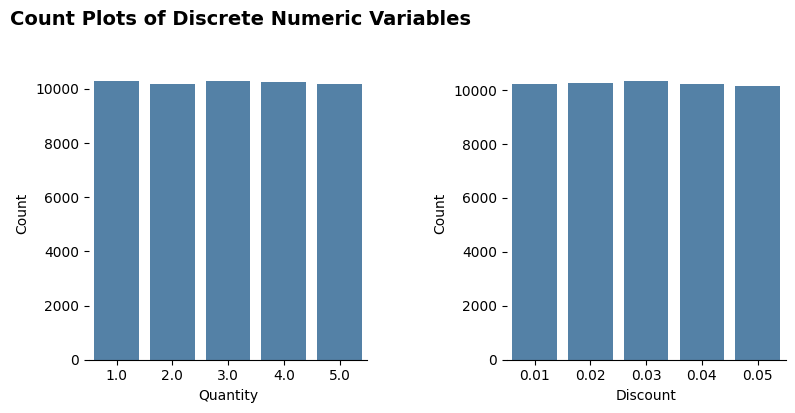

In [6]:
# countplots for selected numeric variables that are discrete (Quantity and Discount)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sns.countplot(data=df_behavior, x="Quantity", ax=axes[0], color="steelblue")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Count")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].spines["left"].set_visible(False)
sns.countplot(data=df_behavior, x="Discount", ax=axes[1], color="steelblue")
axes[1].set_xlabel("Discount")
axes[1].set_ylabel("Count")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].spines["left"].set_visible(False)

fig.suptitle("Count Plots of Discrete Numeric Variables", fontsize=14, fontweight="bold", y=1.02, x=0.3)
plt.tight_layout()
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()

The numeric variables show several different distribution shapes. `Age` is right-skewed, while `Sales`, `Profit`, and `Shipping Cost` show multiple concentrations rather than a single normal-shaped peak. `Browsing Time (min)` is more broadly distributed.

`Quantity` and `Discount` behave as discrete variables and are relatively evenly distributed across their available values.


### 1.5 Outlier Review


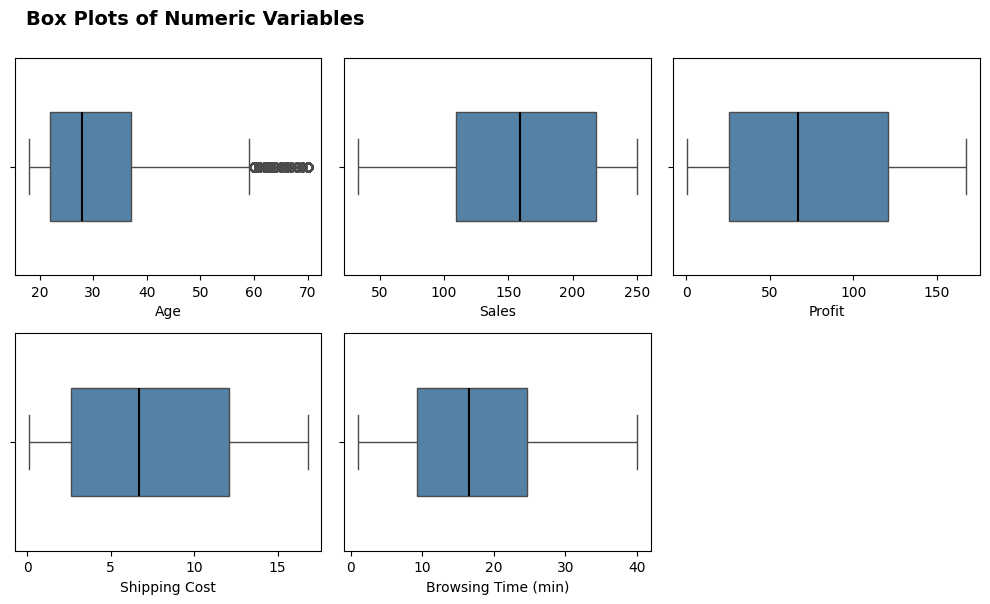

In [7]:
# Boxplots for main numeric variables

boxplot_cols_behavior = ["Age","Sales","Profit","Shipping Cost","Browsing Time (min)"]

cols = 3
rows = (len(boxplot_cols_behavior) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate(boxplot_cols_behavior):
    sns.boxplot(data=df_behavior, x=col, ax=axes[i], color = "steelblue", medianprops={"color": "black", "linewidth": 1.5}, width=0.5)
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Box Plots of Numeric Variables", fontsize=14, fontweight="bold", y=1, x=0.2)
plt.tight_layout()
plt.show()

The boxplots do not show obvious data-quality problems. `Age` has some high-end points, but the observed values remain plausible. The other selected variables stay within the ranges validated during data preparation, so no observations are removed here.


### 1.6 Categorical Distributions


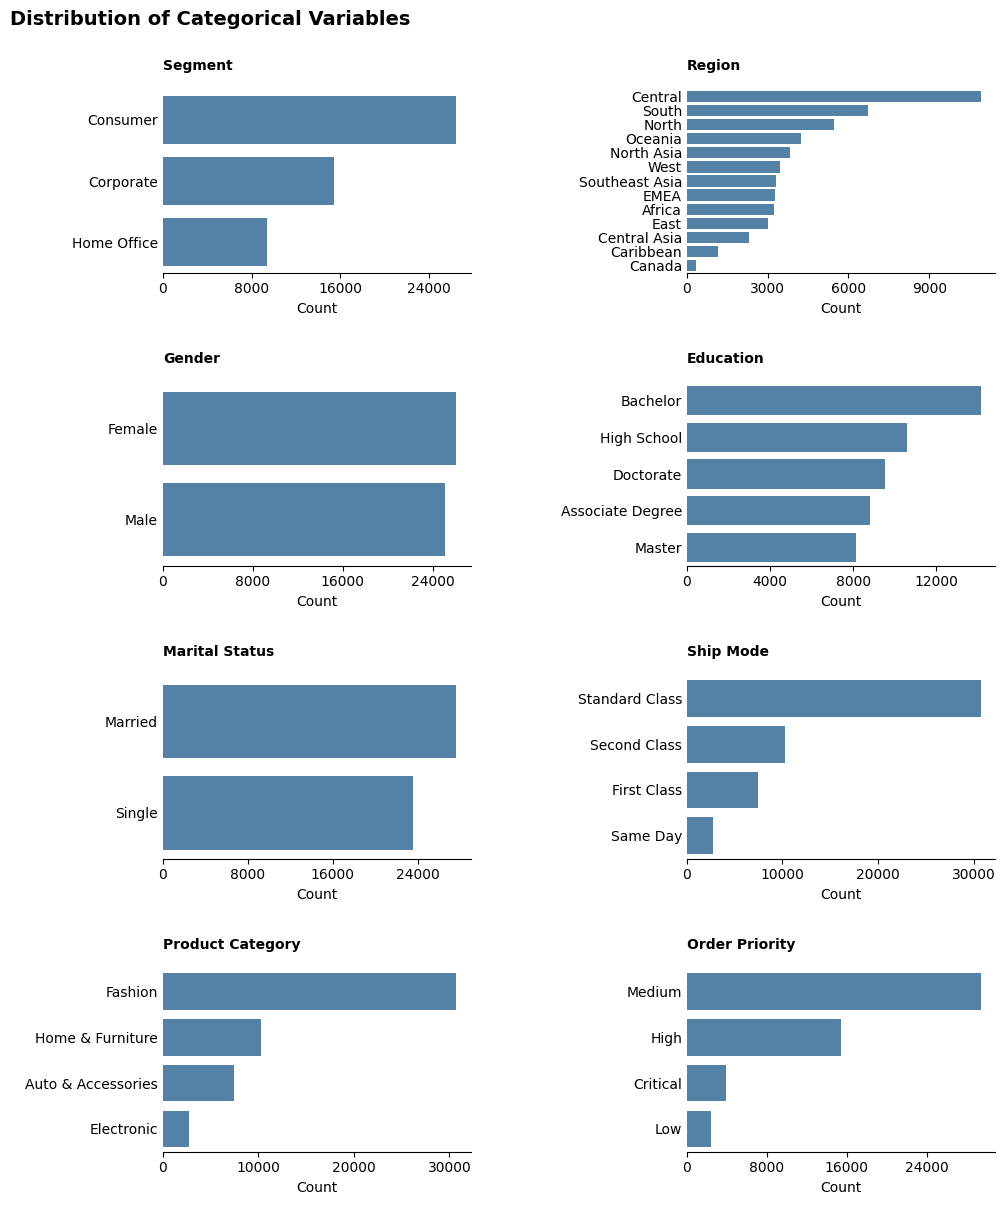

In [8]:
# Bar plots for selected categorical variables
cols = 2
rows = (len(categorical_cols_behavior) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols_behavior):
    order = df_behavior[col].value_counts().index
    
    sns.countplot(data=df_behavior, y=col, order=order, ax=axes[i], color="steelblue")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel(None)
    axes[i].set_title(col, loc="left", pad=14, fontsize=10, fontweight="bold")
    axes[i].tick_params(axis="y", length=0)
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

    axes[i].xaxis.set_major_locator(MaxNLocator(nbins=4))
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
fig.suptitle("Distribution of Categorical Variables", fontsize=14, fontweight="bold", y=1, x=0.2)
plt.tight_layout()
plt.subplots_adjust(wspace=0.7, hspace=0.6)
plt.show();

Several categorical variables are imbalanced. `Consumer` is the largest customer segment, `Standard Class` dominates shipping mode, `Medium` is the most common order priority, and `Fashion` is the largest product category. `Gender` is comparatively balanced.

These differences in representation should be considered when comparing groups later in the analysis.


### 1.7 Selected Group Comparisons

The following plots examine whether important numeric distributions change across product categories or engagement outcomes.


#### 1.7.1 Sales by Product Category


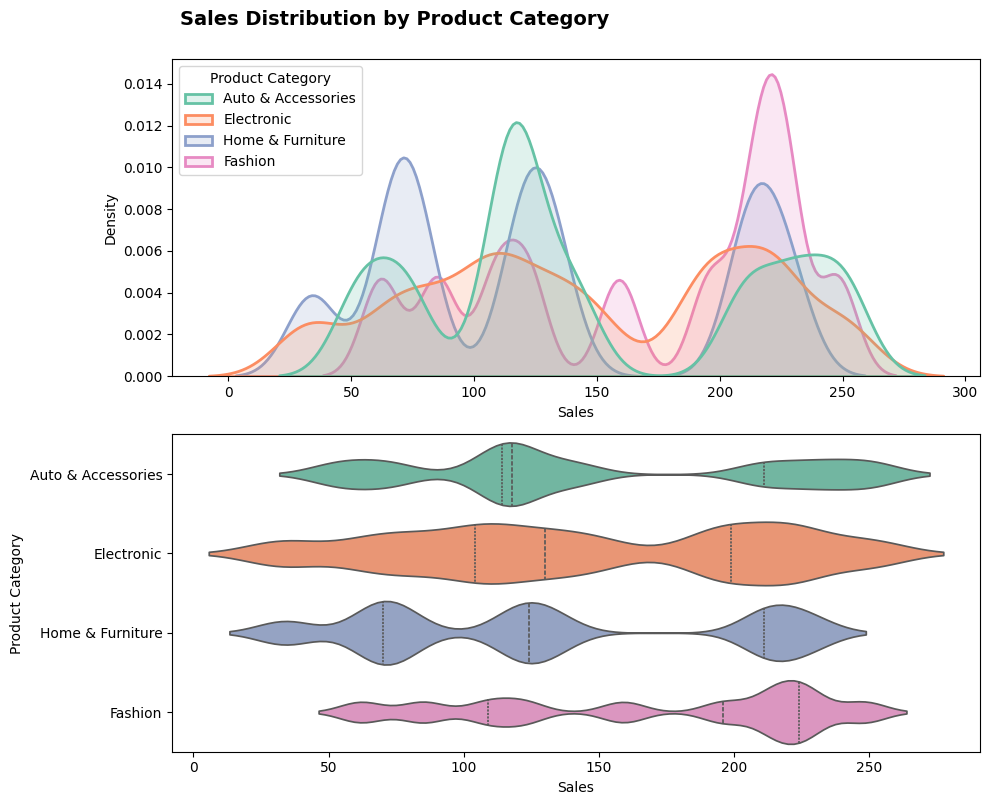

In [9]:
# KDE and violin plots for Sales by Product Category
fig, ax = plt.subplots(2,1, figsize = (10, 8))
ax = ax.flatten()

# KDE plot
sns.kdeplot(data=df_behavior, x="Sales", hue="Product Category", common_norm=False, fill=True, linewidth=2, alpha=0.2, palette= "Set2", ax=ax[0])
ax[0].set_xlabel("Sales")

# Violin plot
sns.violinplot(data=df_behavior, x="Sales", y="Product Category", hue="Product Category", inner="quartile", ax=ax[1], palette="Set2")
ax[1].set_xlabel("Sales")
ax[1].set_ylabel("Product Category")

fig.suptitle("Sales Distribution by Product Category", fontsize=14, fontweight="bold", y=1, x=0.4)
plt.tight_layout()
plt.show()

Sales distributions overlap across categories, but their shapes and concentrations differ. `Fashion` has a stronger concentration in the higher sales range, while other categories show broader or multi-peak patterns. Product category therefore explains part of the structure visible in the overall sales distribution.


#### 1.7.2 Profit by Product Category


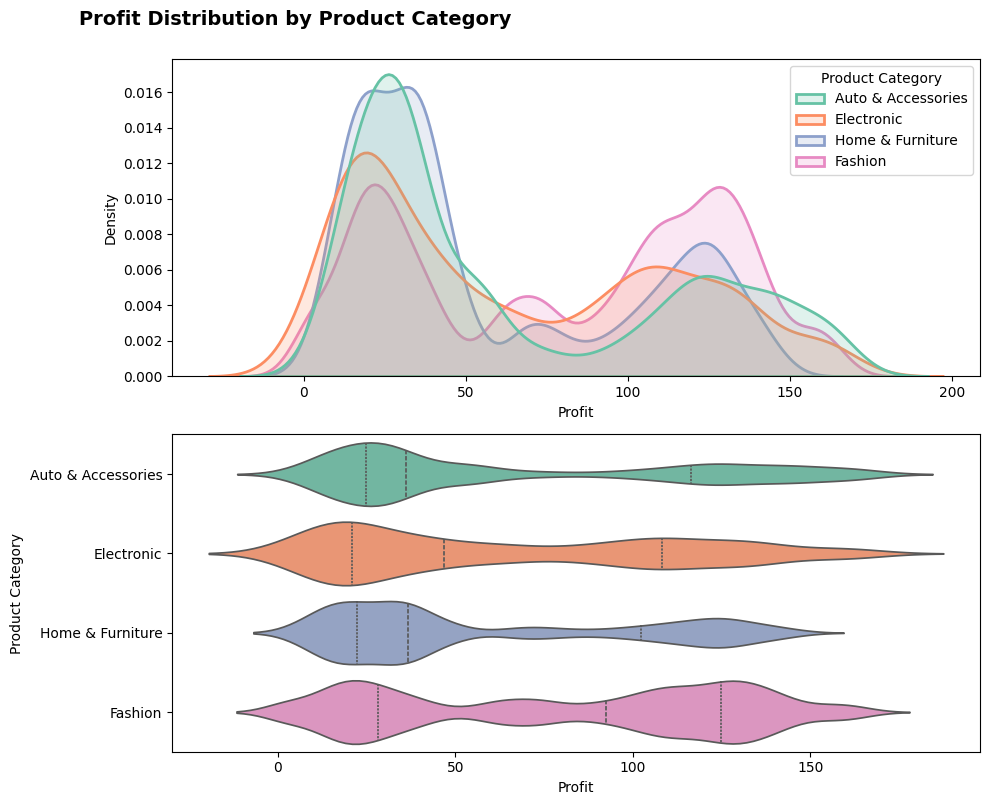

In [10]:
# KDE and violin plots for Profit by Product Category
fig, ax = plt.subplots(2,1, figsize = (10, 8))
ax = ax.flatten()

# KDE plot
sns.kdeplot(data=df_behavior, x="Profit", hue="Product Category", common_norm=False, fill=True, linewidth=2, alpha=0.2, palette= "Set2", ax=ax[0])
ax[0].set_xlabel("Profit")

# Violin plot
sns.violinplot(data=df_behavior, x="Profit", y="Product Category", hue="Product Category", inner="quartile", ax=ax[1], palette="Set2")
ax[1].set_xlabel("Profit")
ax[1].set_ylabel("Product Category")

fig.suptitle("Profit Distribution by Product Category", fontsize=14, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.show()

Profit distributions also overlap substantially across product categories, but several categories show different concentrations in lower- and higher-profit ranges. Product category appears informative, although it does not fully separate profit levels.


#### 1.7.3 Browsing Time by Add-to-Cart Behavior


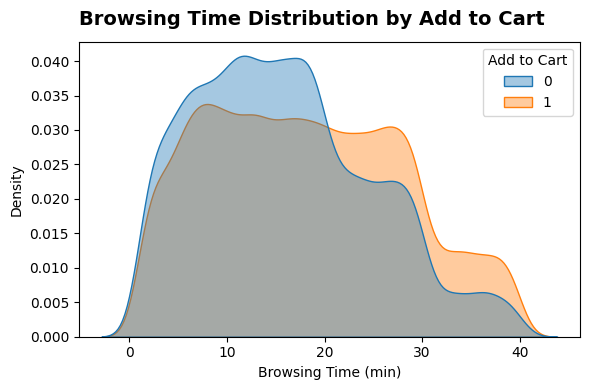

In [11]:
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df_behavior, x="Browsing Time (min)", hue="Add to Cart", common_norm=False, fill=True, alpha=0.4)
plt.title("Browsing Time Distribution by Add to Cart", loc="left", fontsize=14, fontweight="bold", y=1, pad=12)
plt.xlabel("Browsing Time (min)")
plt.tight_layout()
plt.show()

The two browsing-time distributions overlap heavily. Customers who added an item to the cart appear somewhat more represented at longer browsing times, but browsing time alone does not clearly separate the groups.


### 1.8 Dataset 1 Findings

Dataset 1 shows meaningful variation in both purchase and engagement behavior. Several numeric variables are non-normal or multi-modal, and category frequencies are uneven. Product category helps explain some sales and profit patterns, while browsing time shows only limited separation between add-to-cart groups.


## 2. Sales & Customer Insights

This customer-level dataset contains purchasing metrics, churn probability, customer value measures, and retention-related categories.


### 2.1 Load Data


In [12]:
df_sales = pd.read_pickle(DATA_DIR / "df_sales_eda.pkl")
df_sales.shape


(10000, 15)

### 2.2 Analysis Variables


In [ ]:
numeric_cols_sales = ["Purchase_Frequency", "Average_Order_Value","Time_Between_Purchases", "Churn_Probability","Lifetime_Value"]

categorical_cols_sales = [ "Most_Frequent_Category", "Region", "Season","Preferred_Purchase_Times", "Retention_Strategy"]

identifier_cols_sales = ["Customer_ID", "Product_ID", "Transaction_ID"]


### 2.3 Summary Statistics


In [ ]:
summary_stats_sales = (df_sales[numeric_cols_sales].agg(["mean", "median", lambda x: x.mode().iloc[0], "min", "max"]).T.rename(columns={"<lambda>": "mode"}))

summary_stats_sales


,mean,median,mode,min,max
Purchase_Frequency,9.955700,10.00,1.00,1.00,19.00
Average_Order_Value,110.006022,109.93,26.74,20.01,199.96
Time_Between_Purchases,46.885300,47.00,74.00,5.00,89.00
Churn_Probability,0.501552,0.50,0.84,0.00,1.00
Lifetime_Value,5031.930567,5012.18,138.63,100.16,9999.76


The means and medians are close for most variables, and each measure spans a broad but valid range. This suggests relatively even distributions rather than strong skewness.


### 2.4 Numeric Distributions


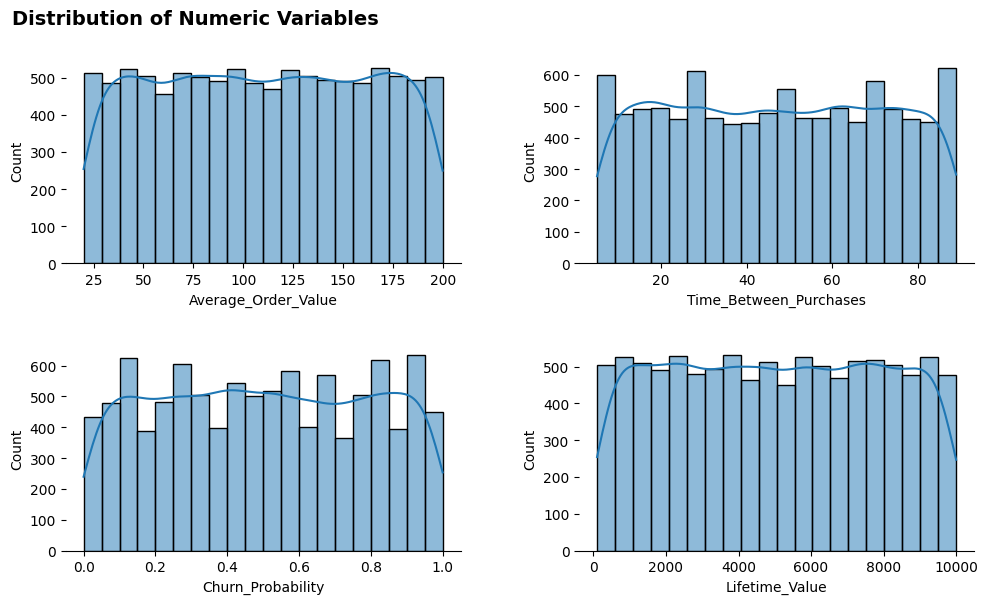

In [15]:
# Histograms for selected numeric variables
bin_settings = {"Average_Order_Value": 20, "Time_Between_Purchases": 20, "Churn_Probability": 20, "Lifetime_Value": 20}
cols = 2
plot_cols = list(bin_settings.keys())
rows = (len(plot_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    sns.histplot(data=df_sales, x=col, bins=bin_settings[col], kde=True, ax=axes[i])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Numeric Variables", fontsize=14, fontweight="bold", y=1, x=0.2)
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

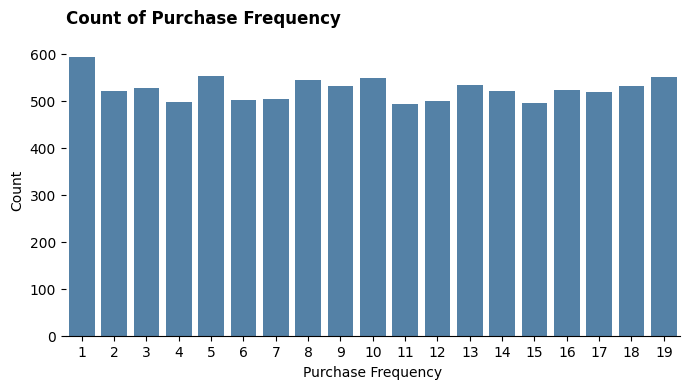

In [16]:
# countplots for selected numeric variables that are discrete (Purchase_Frequency)
plt.figure(figsize=(7, 4))
sns.countplot(data = df_sales, x="Purchase_Frequency", color="steelblue")
plt.title("Count of Purchase Frequency", fontweight="bold", pad=10, y=1.02, loc="left")
plt.xlabel("Purchase Frequency")
plt.ylabel("Count")

axes = plt.gca()
axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_visible(False)
plt.tight_layout()
plt.show()

`Average_Order_Value`, `Time_Between_Purchases`, `Churn_Probability`, and `Lifetime_Value` are spread broadly and fairly evenly across their ranges. `Purchase_Frequency` is also distributed relatively evenly across its discrete values.

The unusually uniform appearance of several variables suggests limited natural concentration or segmentation in this dataset.


### 2.5 Outlier Review


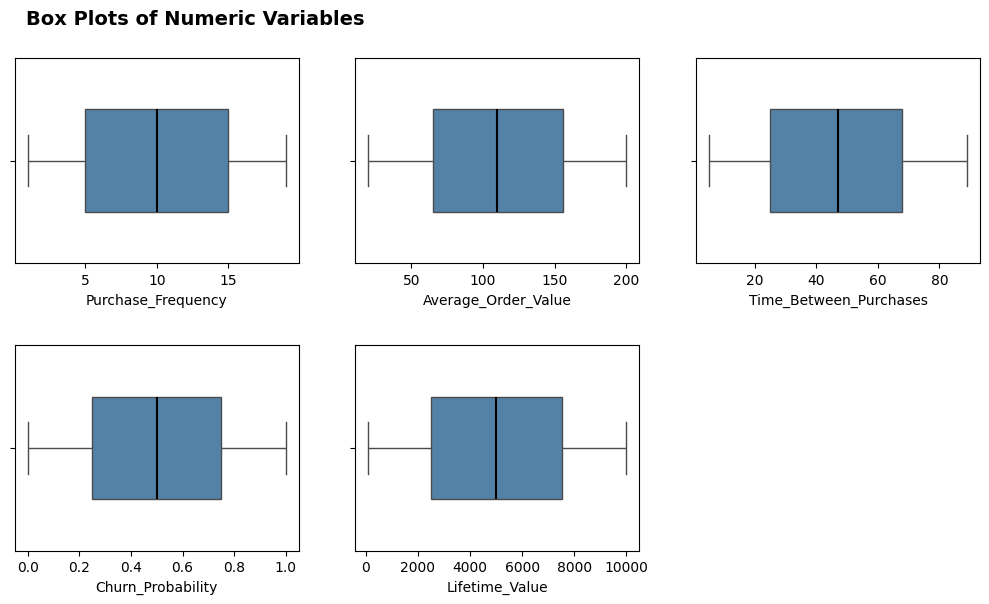

In [17]:
# boxplots for main numeric variables
boxplot_cols_sales = ["Purchase_Frequency","Average_Order_Value","Time_Between_Purchases","Churn_Probability","Lifetime_Value"]

cols = 3
rows = (len(boxplot_cols_sales) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate(boxplot_cols_sales):
    sns.boxplot(data=df_sales, x=col, ax=axes[i], color = "steelblue", medianprops={"color": "black", "linewidth": 1.5}, width=0.5)
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Box Plots of Numeric Variables", fontsize=14, fontweight="bold", y=1, x=0.2)
plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.4)
plt.show()


The boxplots show no obvious extreme outliers or invalid values. Median positions are also consistent with the relatively even distributions observed in the histograms.


### 2.6 Categorical Distributions


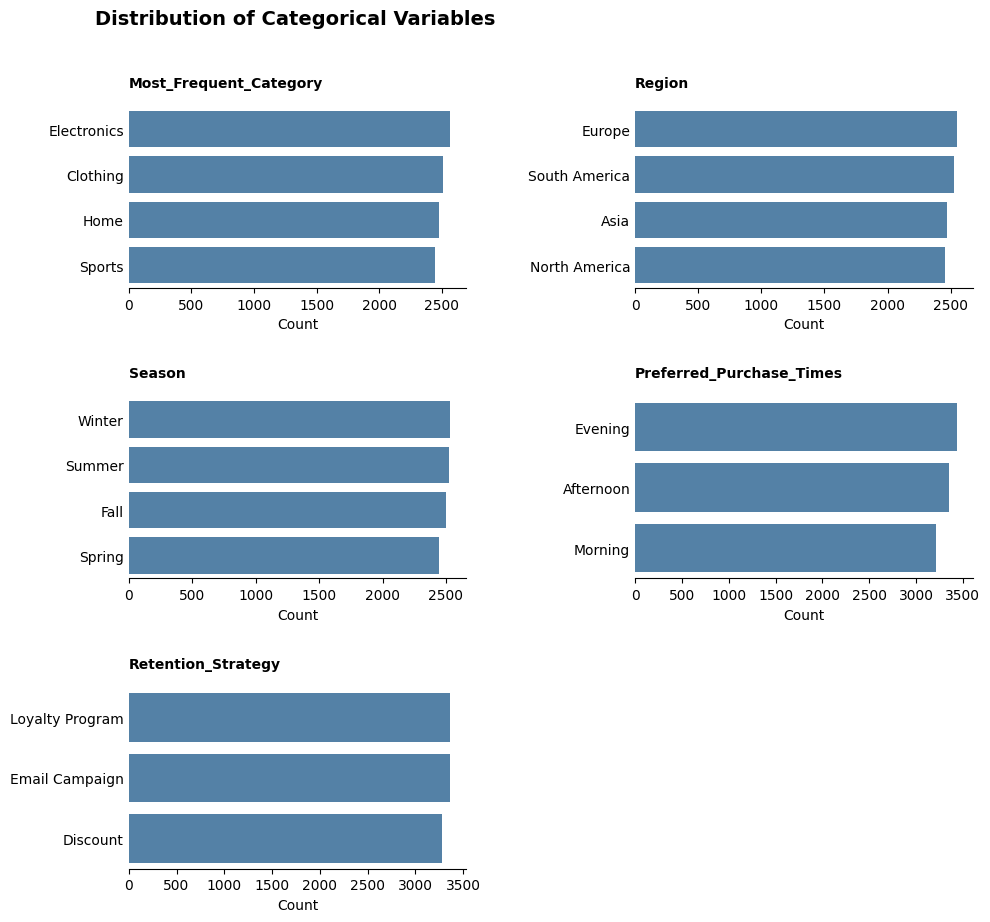

In [18]:
# bar plots for selected categorical variables
cols = 2
rows = (len(categorical_cols_sales) + cols - 1) // cols
fig,axes = plt.subplots(rows, cols, figsize = (10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate (categorical_cols_sales):
    order = df_sales[col].value_counts().index
    sns.countplot(data=df_sales, y=col, order=order, ax=axes[i], color="steelblue")
    axes[i].set_xlabel("Count") 
    axes[i].tick_params(axis="y", length=0)
    axes[i].set_title(col, loc="left", pad=14, fontsize=10, fontweight="bold")
    axes[i].set_ylabel(None)
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Categorical Variables", fontsize=14, fontweight="bold", y=1.02, x=0.3)
plt.tight_layout()
plt.subplots_adjust(wspace=0.5, hspace=0.6)
plt.show()

The categorical variables are also unusually balanced. Product category, region, season, preferred purchase time, and retention strategy all have similar group sizes, with no category strongly dominating the data.


### 2.7 Selected Group Comparisons


#### 2.7.1 Churn Probability by Retention Strategy


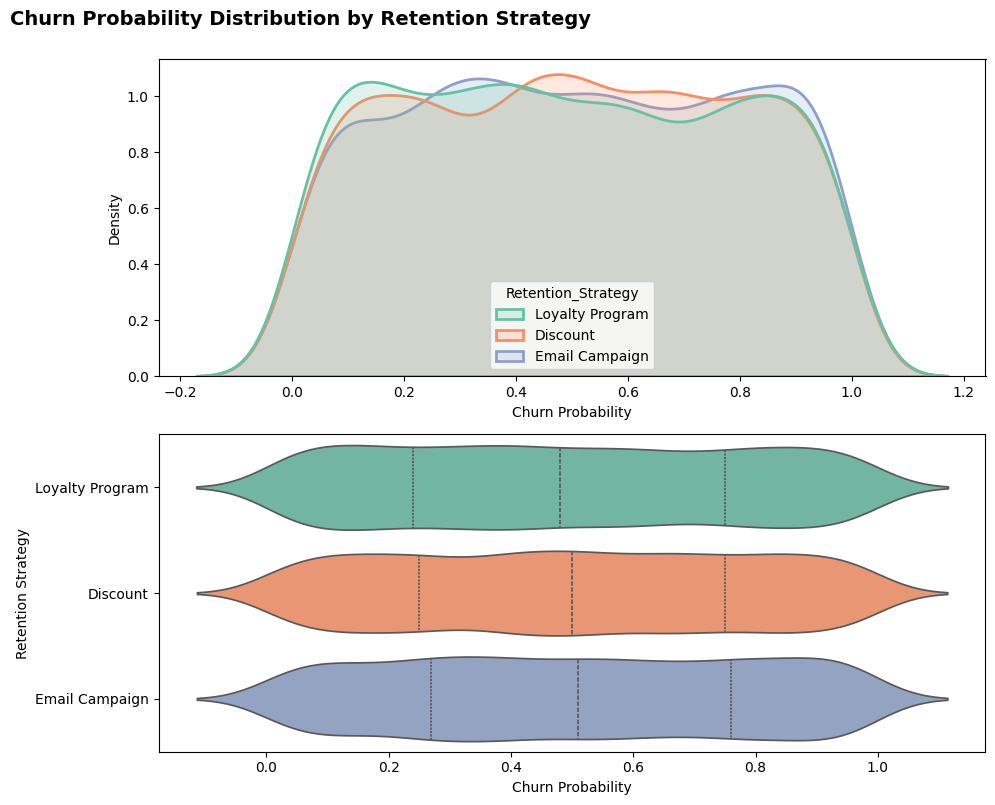

In [19]:
# KDE and violin plots for churn probability by retention strategy
fig, axes = plt.subplots(2,1, figsize=(10, 8))
axes = axes.flatten()

# KDE plot
sns.kdeplot(data=df_sales, x = "Churn_Probability", hue = "Retention_Strategy", common_norm=False, fill=True, alpha=0.2, linewidth=2, palette="Set2", ax=axes[0],)
axes[0].set_xlabel("Churn Probability")

# Violin plot
sns.violinplot(data=df_sales, x = "Churn_Probability", y = "Retention_Strategy", hue = "Retention_Strategy", inner="quartile", ax=axes[1], palette="Set2")
axes[1].set_xlabel("Churn Probability")
axes[1].set_ylabel("Retention Strategy")

fig.suptitle("Churn Probability Distribution by Retention Strategy", fontsize=14, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.show()

Churn probability distributions overlap heavily across retention strategies, with similar spread and quartile positions. Retention strategy does not clearly separate customers by churn probability.


#### 2.7.2 Lifetime Value by Region


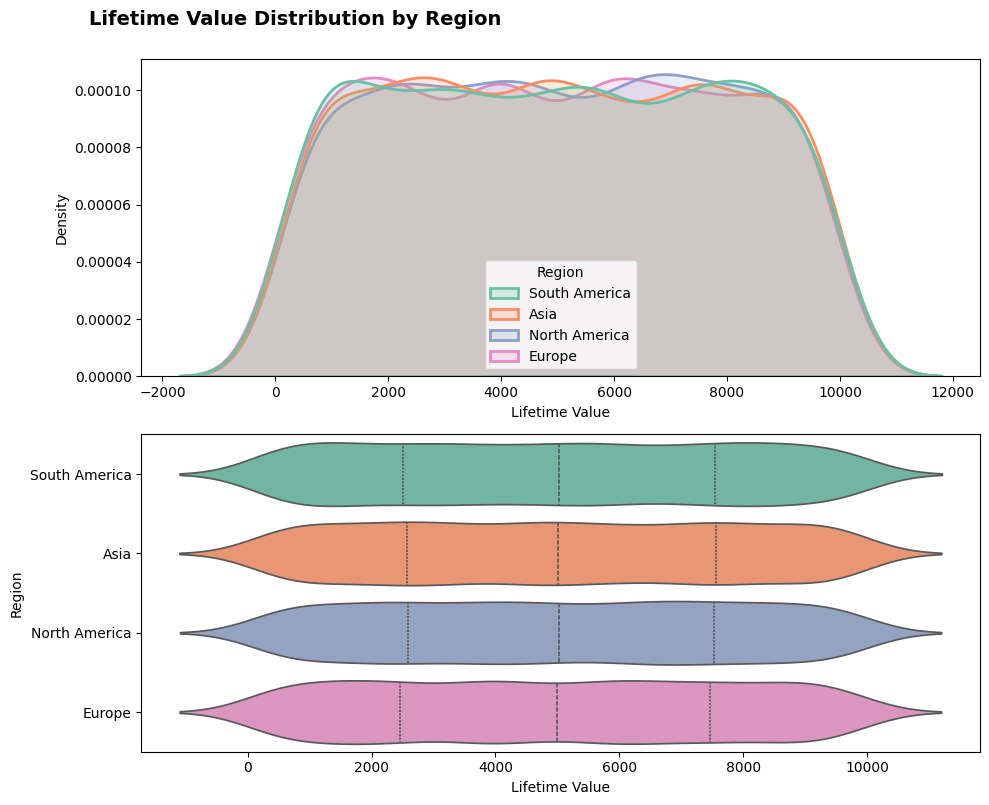

In [20]:
# KDE and violin plots for Lifetime Value by Region
fig, axes = plt.subplots(2,1, figsize=(10, 8))
axes = axes.flatten()

# KDE plot
sns.kdeplot(data=df_sales, x="Lifetime_Value", hue="Region", common_norm=False, fill=True, alpha=0.2, linewidth=2, palette="Set2", ax=axes[0])
axes[0].set_xlabel("Lifetime Value")

# Violin plot
sns.violinplot(data=df_sales, x="Lifetime_Value", y="Region", hue="Region", inner="quartile", ax=axes[1], palette="Set2")
axes[1].set_xlabel("Lifetime Value")
axes[1].set_ylabel("Region")

fig.suptitle("Lifetime Value Distribution by Region", fontsize=14, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.show()

Lifetime value covers a similar range across all regions, and the group distributions overlap strongly. Region provides little visible separation in customer lifetime value.


#### 2.7.3 Average Order Value by Product Category


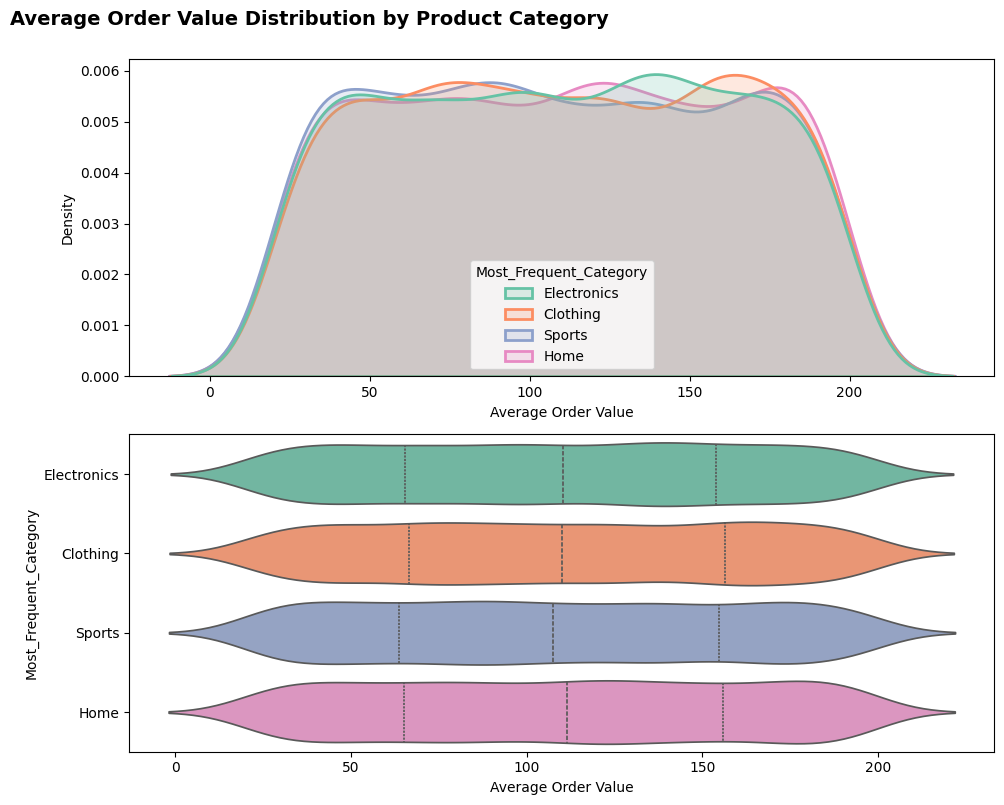

In [21]:
# KDE and violin plots for average order value by most frequent category
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes = axes.flatten()

# KDE plot
sns.kdeplot(data=df_sales,x="Average_Order_Value",hue="Most_Frequent_Category",common_norm=False,fill=True,alpha=0.2,linewidth=2, palette="Set2", ax=axes[0])
axes[0].set_xlabel("Average Order Value")

# Violin plot
sns.violinplot(data=df_sales, x="Average_Order_Value", y="Most_Frequent_Category", hue="Most_Frequent_Category", inner="quartile", ax=axes[1], palette="Set2")
axes[1].set_xlabel("Average Order Value")

fig.suptitle("Average Order Value Distribution by Product Category", fontsize=14, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.show()

Average order value is distributed similarly across product categories. The strong overlap and similar quartiles indicate limited category-level separation.


### 2.8 Dataset 2 Findings

Dataset 2 is technically clean, but its numeric and categorical variables are unusually even and the grouped comparisons show little separation. At this stage, the dataset appears to contain limited analytical signal. Later multivariate and predictive analysis is needed to determine whether these weak patterns persist.


## 3. Customer Churn

This customer-level dataset combines retention, order activity, satisfaction, complaint, and behavioral variables with the binary `Churn` target.


### 3.1 Load Data


In [22]:
df_churn = pd.read_pickle(DATA_DIR / "df_churn_eda.pkl")
df_churn.shape


(5630, 20)

### 3.2 Analysis Variables


In [ ]:
numeric_cols_churn = ["Tenure", "WarehouseToHome", "OrderAmountHikeFromlastYear","CashbackAmount", "HourSpendOnApp", "CouponUsed","OrderCount", "DaySinceLastOrder"]

discrete_numeric_cols_churn = ["CityTier", "NumberOfDeviceRegistered", "SatisfactionScore","NumberOfAddress", "Complain", "Churn"]

categorical_cols_churn = ["PreferredLoginDevice", "PreferredPaymentMode", "Gender","PreferedOrderCat", "MaritalStatus"]

identifier_cols_churn = ["CustomerID"]


### 3.3 Summary Statistics


In [ ]:
summary_cols_churn = numeric_cols_churn + discrete_numeric_cols_churn

summary_stats_churn = (df_churn[summary_cols_churn].agg(["mean", "median", lambda x: x.mode().iloc[0], "min", "max"]).T.rename(columns={"<lambda>": "mode"}))

summary_stats_churn


,mean,median,mode,min,max
Tenure,10.189899,9.00,1.00,0.0,61.00
WarehouseToHome,15.639896,14.00,9.00,5.0,127.00
OrderAmountHikeFromlastYear,15.707922,15.00,14.00,11.0,26.00
CashbackAmount,177.223030,163.28,123.42,0.0,324.99
HourSpendOnApp,2.931535,3.00,3.00,0.0,5.00
CouponUsed,1.751023,1.00,1.00,0.0,16.00
OrderCount,3.008004,2.00,2.00,1.0,16.00
DaySinceLastOrder,4.543491,3.00,3.00,0.0,46.00
CityTier,1.654707,1.00,1.00,1.0,3.00
NumberOfDeviceRegistered,3.688988,4.00,4.00,1.0,6.00


Several variables are right-skewed or count-based. `Tenure` and `WarehouseToHome` have long upper ranges, while `CouponUsed`, `OrderCount`, and `DaySinceLastOrder` are concentrated at lower values. The mean of `Churn` is approximately 0.17, consistent with the class imbalance identified during data preparation.


### 3.4 Numeric and Discrete Distributions


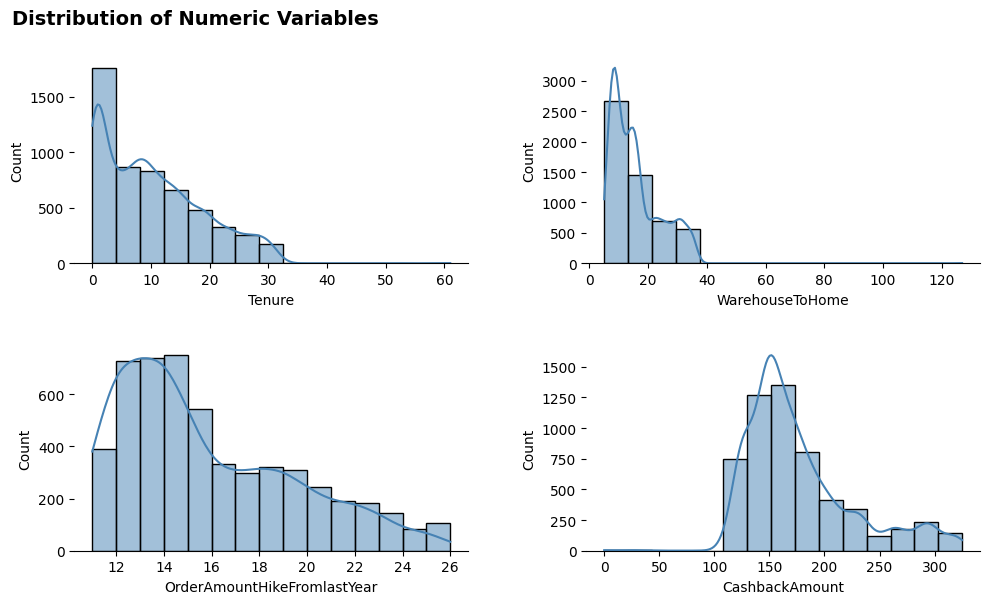

In [25]:
# histograms for numeric variables in churn dataset
bin_settings = {"Tenure": 15, "WarehouseToHome": 15, "OrderAmountHikeFromlastYear": 15, "CashbackAmount": 15}
cols = 2
plot_cols = list(bin_settings.keys())
rows = (len(plot_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    sns.histplot(data=df_churn, x=col, bins=bin_settings[col], kde= True, ax=axes[i], color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Numeric Variables", fontsize=14, fontweight="bold", y=1, x=0.2)
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

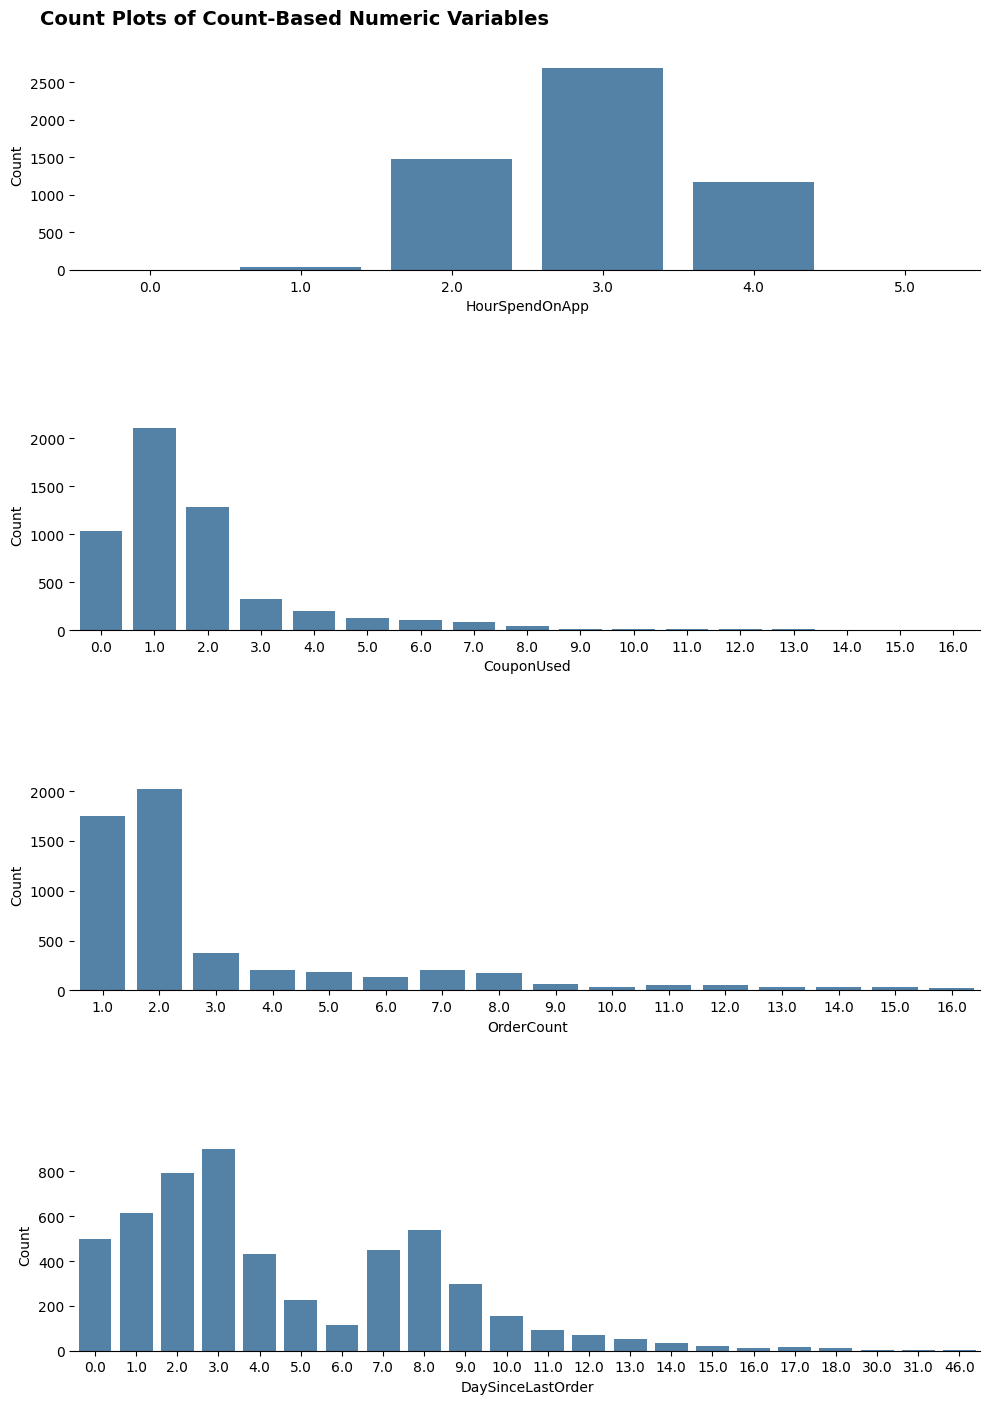

In [26]:
# Countplots for count-based numeric variables
plot_cols = ["HourSpendOnApp", "CouponUsed", "OrderCount", "DaySinceLastOrder"]
fig, axes = plt.subplots(4,1, figsize=(10,14))

for i, col in enumerate(plot_cols):
    sns.countplot(data=df_churn, x=col, ax=axes[i], color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

fig.suptitle("Count Plots of Count-Based Numeric Variables", fontsize=14, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.subplots_adjust(hspace=0.7)
plt.show()

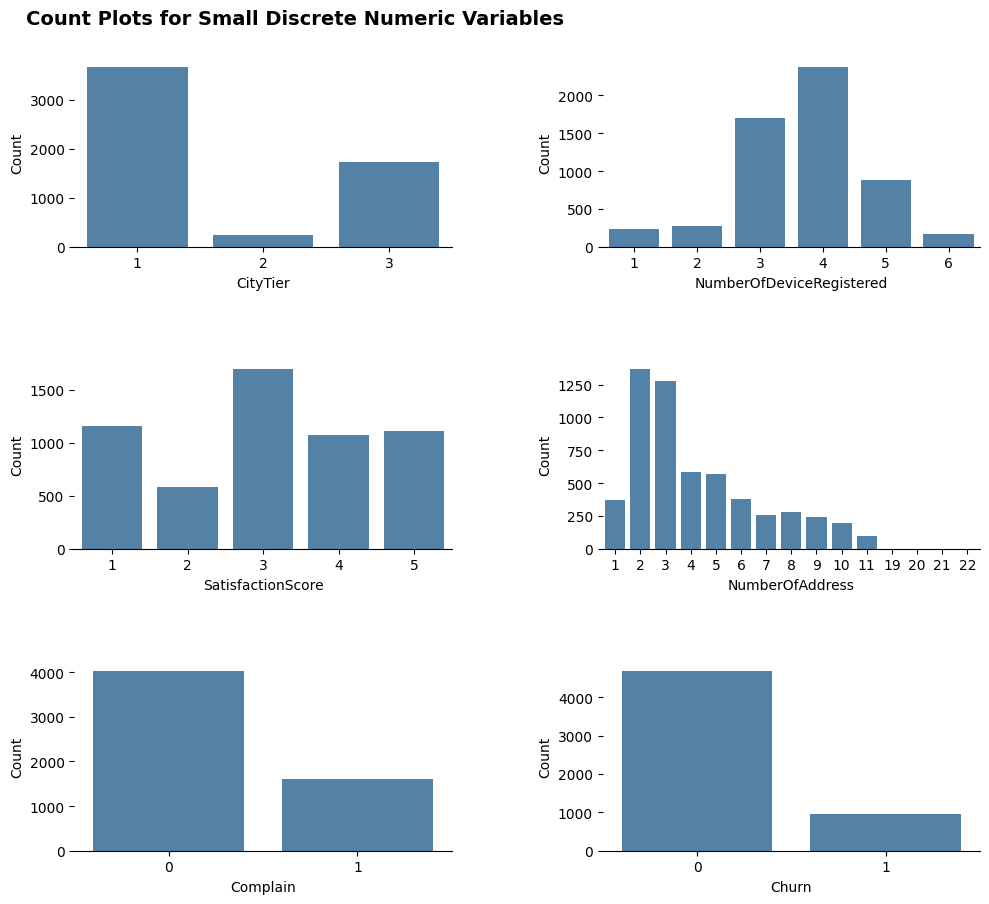

In [27]:
# Count plots for small discrete numeric variables
cols = 2
plot_cols = discrete_numeric_cols_churn 
rows = (len(plot_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.countplot(data=df_churn, x=col, ax=axes[i], color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Count Plots for Small Discrete Numeric Variables", fontsize=14, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.subplots_adjust(wspace = 0.4, hspace=0.6)
plt.show()

`Tenure`, `WarehouseToHome`, `CashbackAmount`, `CouponUsed`, `OrderCount`, and `DaySinceLastOrder` are right-skewed to varying degrees. Several other variables are discrete by design, including city tier, satisfaction score, complaint status, and churn.

These shapes suggest that median- and distribution-based comparisons may be more informative than assuming normality.


### 3.5 Outlier Review


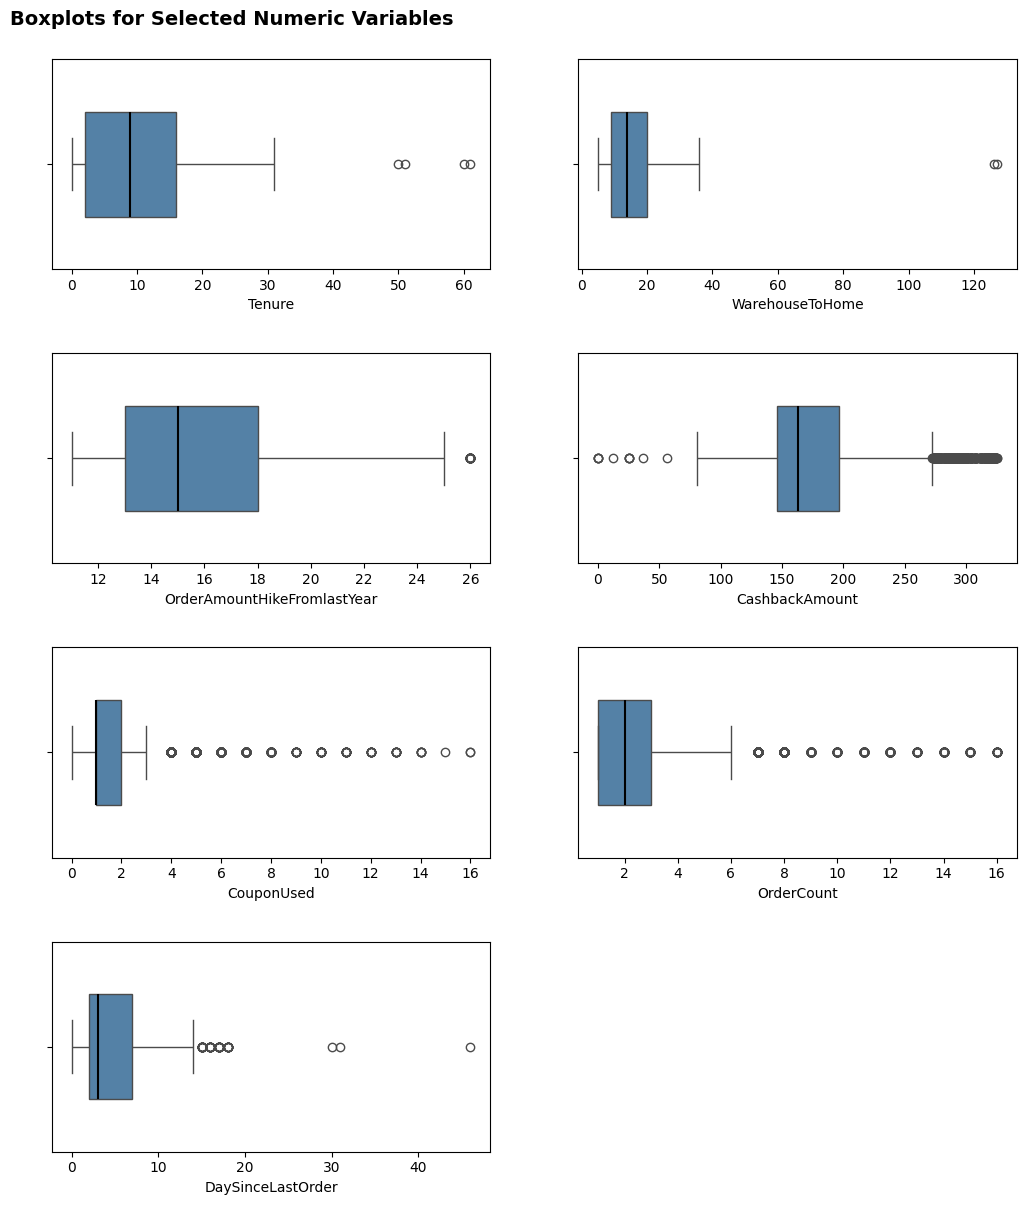

In [28]:
boxplot_cols_churn = ["Tenure","WarehouseToHome","OrderAmountHikeFromlastYear","CashbackAmount","CouponUsed","OrderCount","DaySinceLastOrder"]

cols = 2
rows = (len(boxplot_cols_churn) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate(boxplot_cols_churn):
    sns.boxplot(data=df_churn, x=col, ax=axes[i], color="steelblue", width=0.5, medianprops={"color": "black", "linewidth": 1.5})
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Boxplots for Selected Numeric Variables", fontsize=14, fontweight="bold", y=1, x=0.2)
plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.4)
plt.show()

High-end values are visible in several variables, especially `WarehouseToHome`, `CouponUsed`, `OrderCount`, and `DaySinceLastOrder`. Because these values remain plausible and passed the earlier logical checks, they are retained rather than removed automatically.


### 3.6 Categorical Distributions


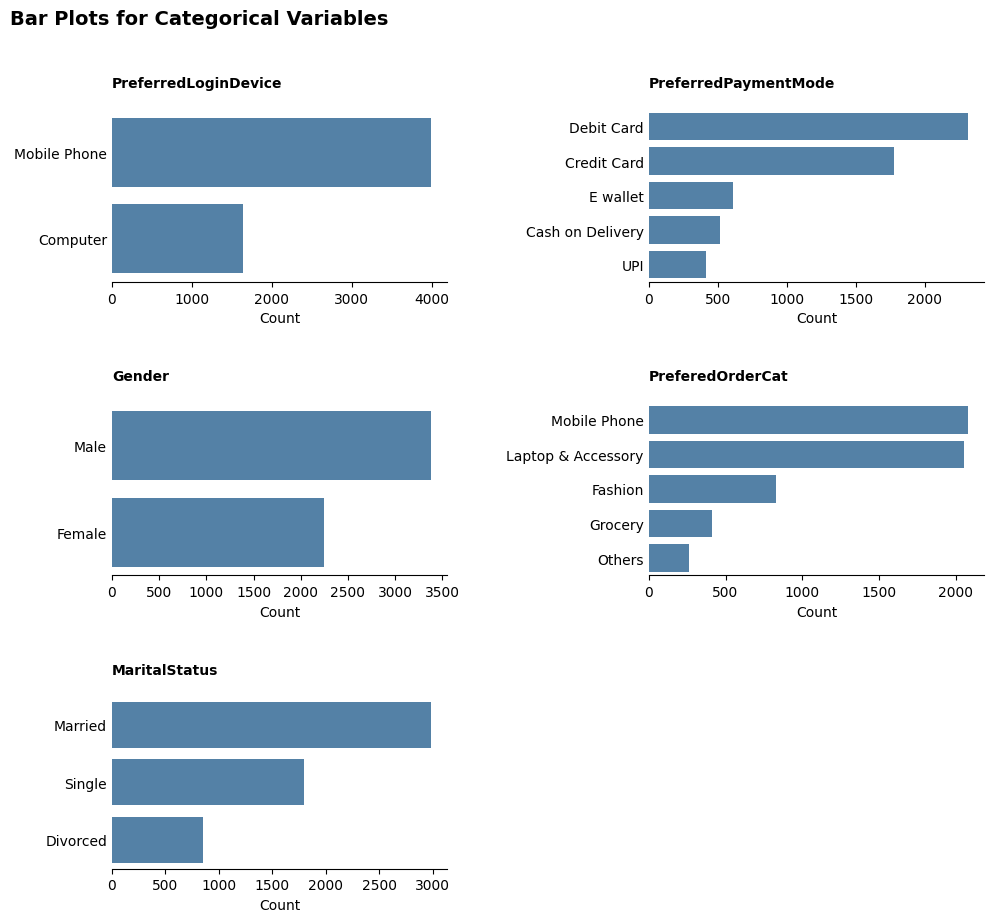

In [29]:
# Bar plots for categorical variables
cols = 2
plot_cols = categorical_cols_churn
rows = (len(plot_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    order = df_churn[col].value_counts().index
    sns.countplot(data=df_churn, y=col, order=order, ax=axes[i], color="steelblue")
    axes[i].set_xlabel("Count")
    axes[i].tick_params(axis="y", length=0)
    axes[i].set_ylabel(None)
    axes[i].set_title(col, loc="left", pad=16, fontsize=10, fontweight="bold")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Bar Plots for Categorical Variables", fontsize=14, fontweight="bold", y=1.02, x=0.2)
plt.tight_layout()
plt.subplots_adjust(wspace=0.6, hspace=0.7)
plt.show()

The categorical variables are not evenly distributed. Mobile phone login, card-based payment methods, several major order categories, and married customers represent larger shares of the dataset. These imbalances provide useful context for later churn comparisons.


### 3.7 Churn-Related Group Comparisons

Because churn is the main outcome in this dataset, selected distributions are compared directly between churned and non-churned customers.


#### 3.7.1 Tenure by Churn


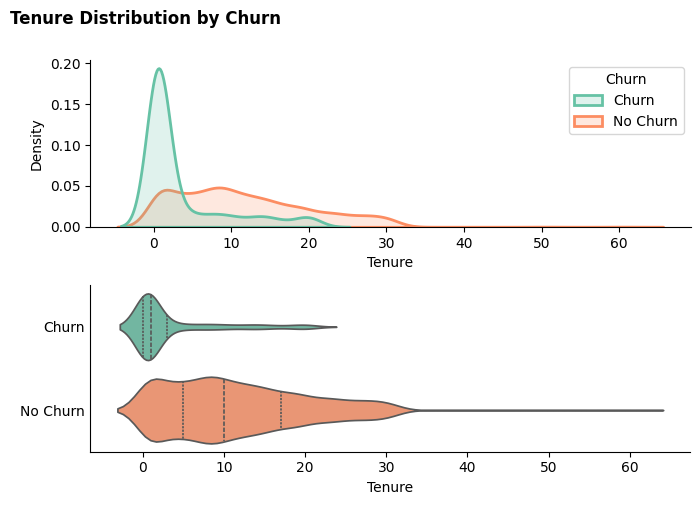

In [30]:
# KDE and violin plots for churn probability by tenure
churn_labels = df_churn["Churn"].map({0: "No Churn", 1: "Churn"})

fig, axes = plt.subplots(2,1, figsize=(7, 5))
axes = axes.flatten()

# KDE plot
sns.kdeplot(data=df_churn, x = "Tenure", hue = churn_labels, common_norm=False, fill=True, alpha=0.2, linewidth=2, palette="Set2", ax=axes[0])
axes[0].set_xlabel("Tenure")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Violin plot
sns.violinplot(data=df_churn, x = "Tenure", y = churn_labels, hue = churn_labels, inner="quartile", ax=axes[1], palette="Set2")
axes[1].set_xlabel("Tenure")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", length=0)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle("Tenure Distribution by Churn", fontsize=12, fontweight="bold", y=1, x=0.2)
plt.tight_layout()
plt.show()

`Tenure` shows the clearest separation. Churned customers are strongly concentrated at low tenure values, while non-churned customers extend across a much wider tenure range. This makes tenure an important candidate variable for later churn modeling.


#### 3.7.2 Days Since Last Order by Churn


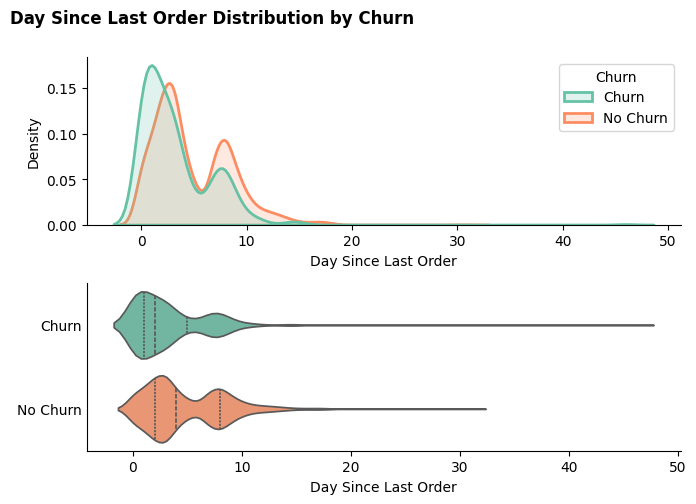

In [31]:
fig, axes = plt.subplots(2,1, figsize=(7, 5))
axes = axes.flatten()

# KDE plot
sns.kdeplot(data= df_churn, x = "DaySinceLastOrder", hue = churn_labels, common_norm=False, fill=True, alpha=0.2, linewidth=2, palette="Set2", ax=axes[0])
axes[0].set_xlabel("Day Since Last Order")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Violin plot
sns.violinplot(data=df_churn, x = "DaySinceLastOrder", y = churn_labels, hue = churn_labels, inner="quartile", ax=axes[1], palette="Set2")
axes[1].set_xlabel("Day Since Last Order")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", length=0)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle("Day Since Last Order Distribution by Churn", fontsize=12, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.show()

Both churn groups are right-skewed and overlap substantially. The distribution shape differs somewhat across groups, but `DaySinceLastOrder` does not clearly separate churn on its own.


#### 3.7.3 Cashback Amount by Churn


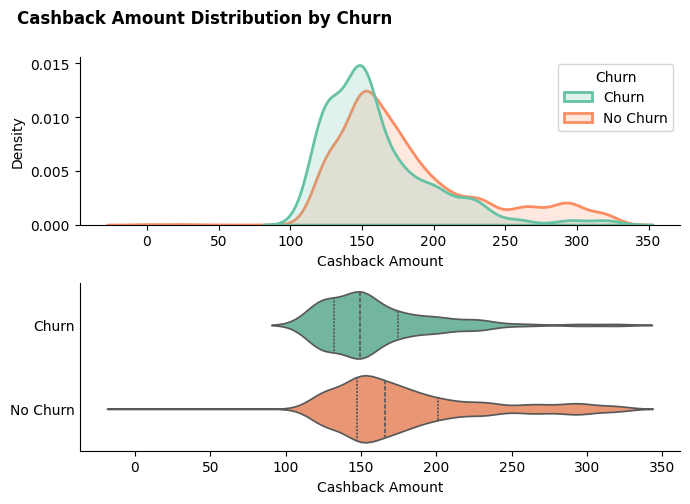

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(7, 5))
axes = axes.flatten()

# KDE plot
sns.kdeplot(data=df_churn,x="CashbackAmount",hue=churn_labels,common_norm=False,fill=True,alpha=0.2,linewidth=2,palette="Set2",ax=axes[0])
axes[0].set_xlabel("Cashback Amount")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Violin plot
sns.violinplot(data=df_churn,x="CashbackAmount",y=churn_labels,hue=churn_labels,inner="quartile",palette="Set2",ax=axes[1])
axes[1].set_xlabel("Cashback Amount")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", length=0)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle("Cashback Amount Distribution by Churn", fontsize=12, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.show()

The groups overlap strongly in the middle cashback range. Non-churned customers extend further into higher cashback values, suggesting a possible relationship that should be evaluated together with other features.


#### 3.7.4 Warehouse-to-Home Distance by Churn


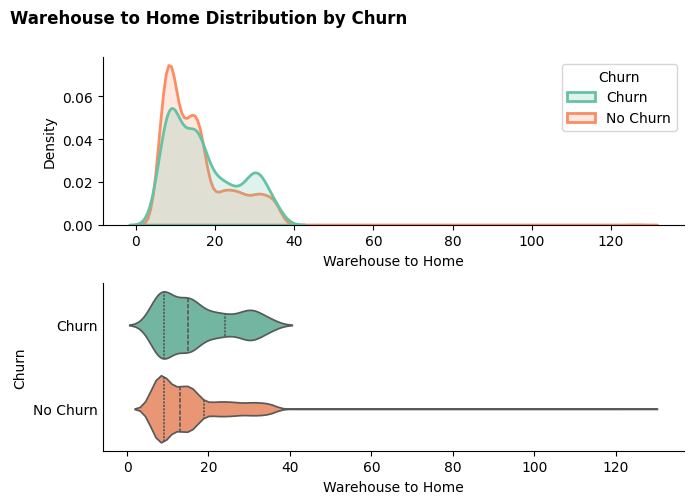

In [33]:
# KDE and violin plots for WarehouseToHome by churn
fig, axes = plt.subplots(2, 1, figsize=(7, 5))
axes = axes.flatten()

# KDE plot
sns.kdeplot(data=df_churn, x="WarehouseToHome", hue=churn_labels, common_norm=False, fill=True, alpha=0.2, linewidth=2, palette="Set2", ax=axes[0])
axes[0].set_xlabel("Warehouse to Home")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
# Violin plot
sns.violinplot(data=df_churn, x="WarehouseToHome", y=churn_labels, hue=churn_labels, inner="quartile", palette="Set2", ax=axes[1])
axes[1].set_xlabel("Warehouse to Home")
axes[1].set_ylabel("Churn")
axes[1].tick_params(axis="y", length=0)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
fig.suptitle("Warehouse to Home Distribution by Churn", fontsize=12, fontweight="bold", y=1, x=0.3)
plt.tight_layout()
plt.show()

Both groups are right-skewed, but churned customers show relatively more density at higher `WarehouseToHome` values. The overlap remains substantial, so this variable is potentially informative rather than independently decisive.


#### 3.7.5 Churn Rate by Satisfaction Score


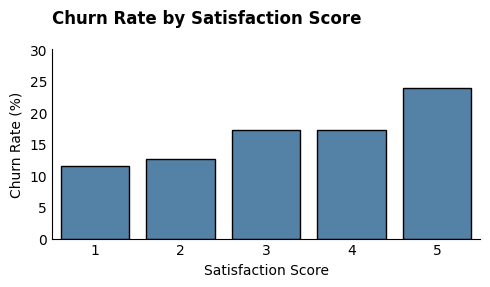

In [34]:
# Calculate churn rate percentage by SatisfactionScore
satisfaction_churn_rate = (df_churn.groupby("SatisfactionScore")["Churn"].mean().reset_index())

satisfaction_churn_rate["Churn_Percent"] = satisfaction_churn_rate["Churn"] * 100

# Bar plot for churn rate by Satisfaction Score
plt.figure(figsize=(5, 3))
ax = sns.barplot(data=satisfaction_churn_rate,x="SatisfactionScore",y="Churn_Percent",color="steelblue", edgecolor="black")

ax.set_title("Churn Rate by Satisfaction Score", loc="left", fontsize=12, pad=12,fontweight="bold", y=1.05, x=0)
ax.set_xlabel("Satisfaction Score")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 30)
axes = plt.gca()
axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

Churn rate is not monotonically lower at higher satisfaction scores; in this dataset, score 5 has the highest observed churn rate. This indicates that satisfaction score should not be interpreted as a simple standalone explanation of churn.


### 3.8 Dataset 3 Findings

Dataset 3 shows the strongest churn-related patterns in this notebook. `Tenure` provides the clearest group separation, while `WarehouseToHome`, `CashbackAmount`, and `DaySinceLastOrder` show weaker but potentially useful differences. The target remains imbalanced, so later modeling should use evaluation metrics beyond accuracy.


## 4. Purchase Experience

This transaction-level dataset contains customer demographics, product and payment information, session behavior, delivery experience, order value, and customer ratings.


### 4.1 Load Data


In [ ]:
df_purchase_experience = pd.read_pickle( DATA_DIR / "df_purchase_experience_eda.pkl")
df_purchase_experience.shape


(5000, 18)

### 4.2 Analysis Variables


In [ ]:
continuous_numeric_cols_purchase = ["Age", "Unit_Price", "Discount_Amount", "Total_Amount","Session_Duration_Minutes", "Delivery_Time_Days"]

discrete_numeric_cols_purchase = ["Quantity", "Pages_Viewed", "Customer_Rating"]

categorical_cols_purchase = ["Gender", "City", "Product_Category", "Payment_Method", "Device_Type", "Is_Returning_Customer"]

identifier_cols_purchase = ["Order_ID", "Customer_ID"]


### 4.3 Summary Statistics


In [ ]:
summary_cols_purchase = (continuous_numeric_cols_purchase+ discrete_numeric_cols_purchase)

summary_stats_purchase = (df_purchase_experience[summary_cols_purchase].agg(["mean", "median", lambda x: x.mode().iloc[0], "min", "max"]).T.rename(columns={"<lambda>": "mode"}))

summary_stats_purchase


,mean,median,mode,min,max
Age,35.032600,35.00,18.00,18.00,75.00
Unit_Price,455.834120,182.95,30.10,5.18,7159.45
Discount_Amount,24.852804,0.00,0.00,0.00,1525.55
Total_Amount,983.108914,337.91,23.05,7.87,22023.90
Session_Duration_Minutes,14.573400,13.00,9.00,1.00,73.00
Delivery_Time_Days,6.497000,6.00,5.00,1.00,25.00
Quantity,2.220000,2.00,1.00,1.00,5.00
Pages_Viewed,8.984200,9.00,8.00,1.00,24.00
Customer_Rating,3.902800,4.00,5.00,1.00,5.00


`Unit_Price`, `Discount_Amount`, and `Total_Amount` have means substantially above their medians, indicating strong right-skew. `Session_Duration_Minutes` and `Delivery_Time_Days` also have longer upper tails. `Quantity`, `Pages_Viewed`, and `Customer_Rating` are discrete and are examined with count plots.


### 4.4 Numeric and Discrete Distributions


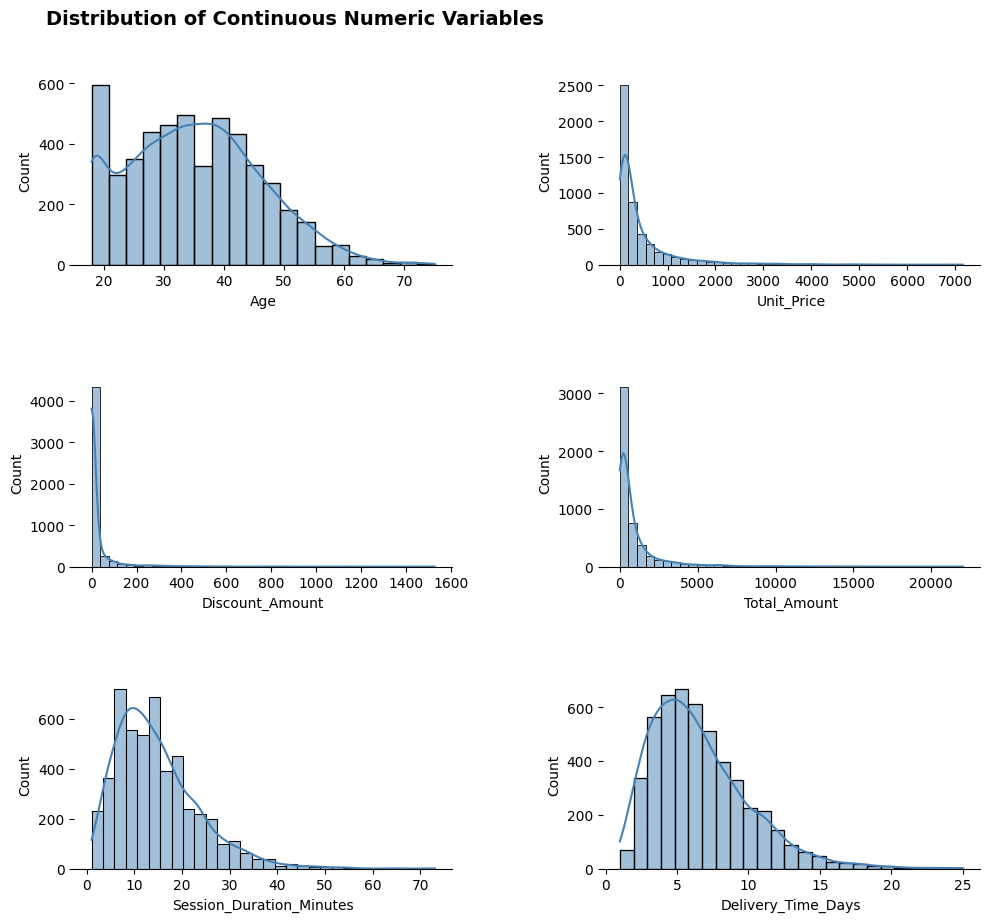

In [38]:
# Histograms for continuous numeric variables
bin_settings = {"Age": 20, "Unit_Price": 40, "Discount_Amount": 40, "Total_Amount": 40, "Session_Duration_Minutes": 30, "Delivery_Time_Days": 25}
cols = 2
plot_cols = list(bin_settings.keys())
rows = (len(plot_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    sns.histplot(data=df_purchase_experience, x=col, bins=bin_settings[col], kde= True, ax=axes[i], color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Continuous Numeric Variables", fontsize=14, fontweight="bold", y=1.02, x=0.3)
plt.tight_layout()
plt.subplots_adjust(wspace=0.4, hspace=0.6)
plt.show()

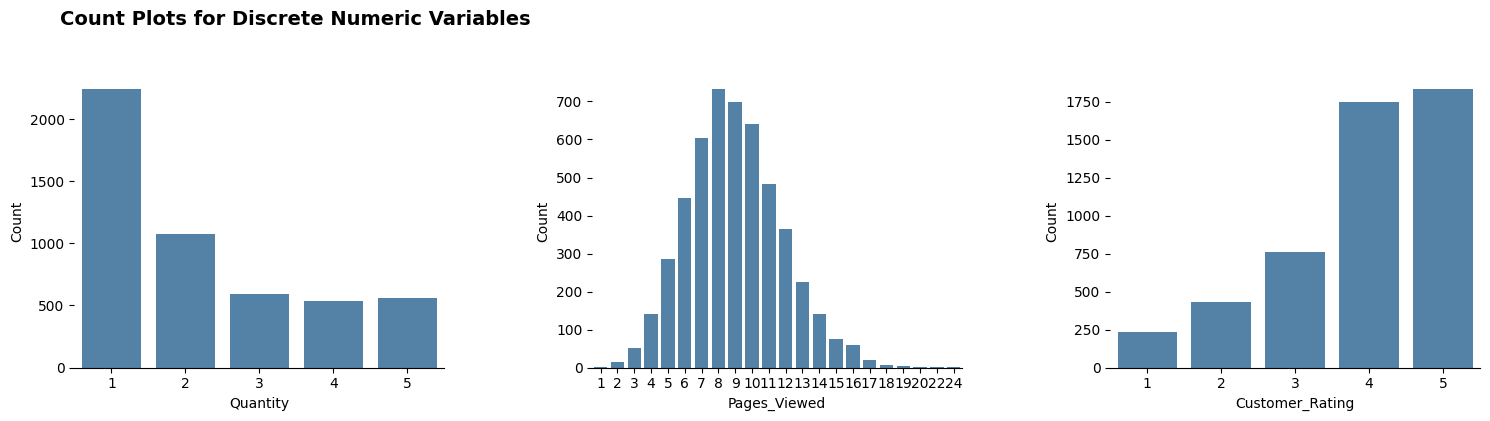

In [39]:
fig,axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(discrete_numeric_cols_purchase):
    sns.countplot(data=df_purchase_experience, x=col, ax=axes[i], color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

fig.suptitle("Count Plots for Discrete Numeric Variables", fontsize=14, fontweight="bold", y=1.04, x=0.2)
plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()

The monetary variables are strongly right-skewed, especially `Unit_Price`, `Discount_Amount`, and `Total_Amount`. Most transactions are lower-value, while a smaller number of purchases extend far into the upper range.

`Quantity` is concentrated at small order sizes, `Pages_Viewed` is centered around the middle of its range, and customer ratings are concentrated toward higher scores.


### 4.5 Outlier Review


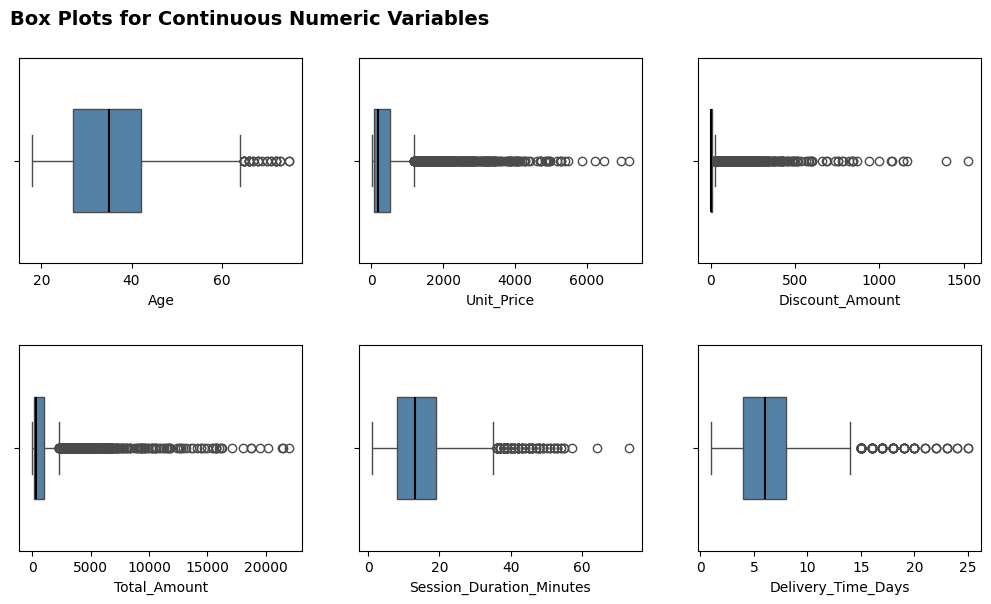

In [ ]:
boxplot_cols_purchase = ["Age", "Unit_Price", "Discount_Amount","Total_Amount", "Session_Duration_Minutes","Delivery_Time_Days"]

cols = 3
rows = (len(boxplot_cols_purchase) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate(boxplot_cols_purchase):
    sns.boxplot(
        data=df_purchase_experience,
        x=col,
        ax=axes[i],
        color="steelblue",
        medianprops={"color": "black", "linewidth": 1.5},
        width=0.5
    )
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Box Plots for Continuous Numeric Variables",fontsize=14,fontweight="bold",y=1,x=0.25)
plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.4)
plt.show()


The strongest high-end outlier patterns occur in `Unit_Price`, `Discount_Amount`, and `Total_Amount`. These observations are retained because they are valid within the earlier logical checks and may represent genuinely expensive products or large transactions.


### 4.6 Categorical Distributions


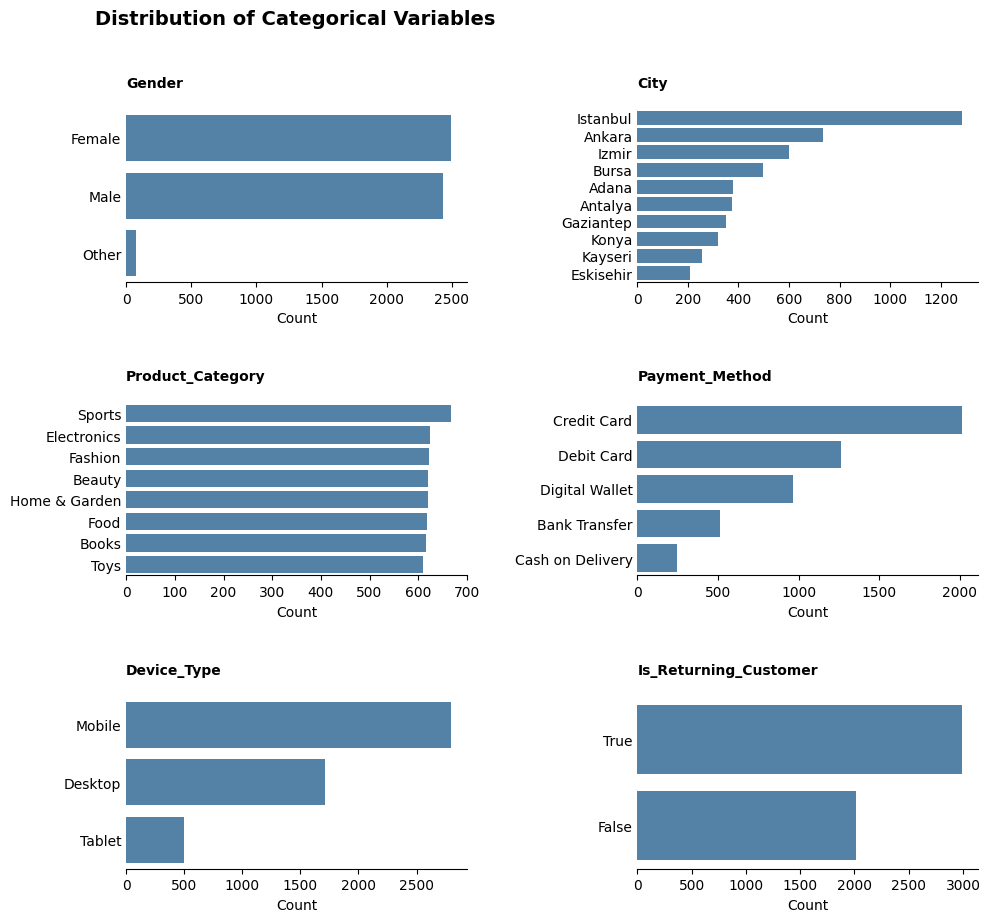

In [41]:
# Bar plots for selected categorical variables
cols = 2
rows = (len(categorical_cols_purchase) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols_purchase):
    order = df_purchase_experience[col].value_counts().index
    
    sns.countplot(data=df_purchase_experience, y=col, order=order, ax=axes[i], color="steelblue")
    axes[i].set_xlabel("Count")
    axes[i].tick_params(axis="y", length=0)
    axes[i].set_ylabel(None)
    axes[i].set_title(col, loc="left", pad=16, fontsize=10, fontweight="bold")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["left"].set_visible(False)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
fig.suptitle("Distribution of Categorical Variables", fontsize=14, fontweight="bold", y=1.02, x=0.3)
plt.tight_layout()
plt.subplots_adjust(wspace=0.5, hspace=0.7)
plt.show();

`Product_Category` is relatively balanced, while `City`, `Payment_Method`, `Device_Type`, and returning-customer status are more uneven. Istanbul, credit card, mobile devices, and returning customers are the largest groups within those variables.


### 4.7 Selected Group Comparisons


#### 4.7.1 Customer Rating by Delivery Time Group


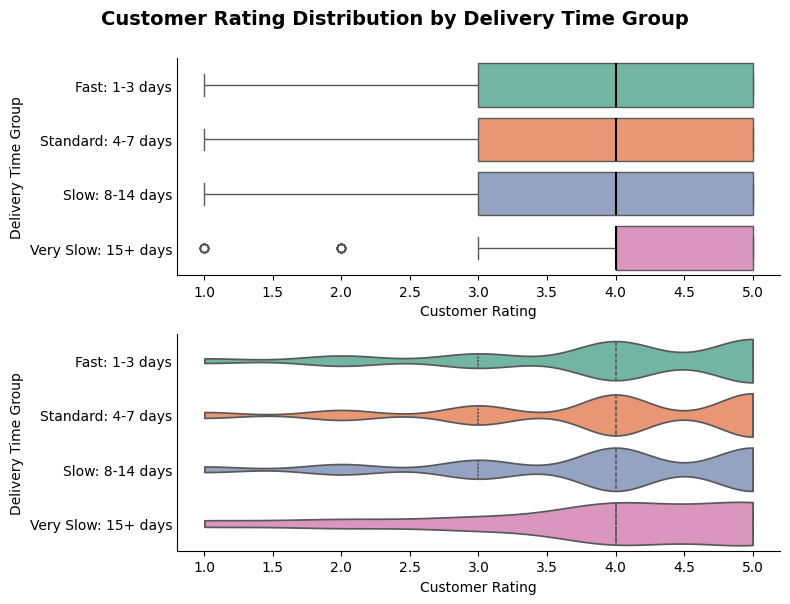

In [ ]:
delivery_bins = [0, 3, 7, 14,df_purchase_experience["Delivery_Time_Days"].max()]
delivery_labels = ["Fast: 1-3 days","Standard: 4-7 days","Slow: 8-14 days","Very Slow: 15+ days"]

delivery_time_group = pd.cut(df_purchase_experience["Delivery_Time_Days"],bins=delivery_bins, labels=delivery_labels,include_lowest=True)

fig, axes = plt.subplots(2, 1, figsize=(8, 6))

sns.boxplot(data=df_purchase_experience,x="Customer_Rating", y=delivery_time_group,hue=delivery_time_group,palette="Set2",legend=False,medianprops={"color": "black", "linewidth": 1.5},ax=axes[0])
axes[0].set_xlabel("Customer Rating")
axes[0].set_ylabel("Delivery Time Group")
axes[0].tick_params(axis="y", length=0)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

sns.violinplot(data=df_purchase_experience,x="Customer_Rating",y=delivery_time_group, hue=delivery_time_group,palette="Set2",legend=False,inner="quartile",cut=0,ax=axes[1])
axes[1].set_xlabel("Customer Rating")
axes[1].set_ylabel("Delivery Time Group")
axes[1].tick_params(axis="y", length=0)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle("Customer Rating Distribution by Delivery Time Group",fontsize=14,fontweight="bold",y=1)
plt.tight_layout()
plt.show()


Customer rating distributions are similar across delivery-time groups. Median ratings remain near 4, and the groups overlap substantially. Delivery time alone does not show a strong relationship with rating in this comparison.


#### 4.7.2 Total Amount by Product Category


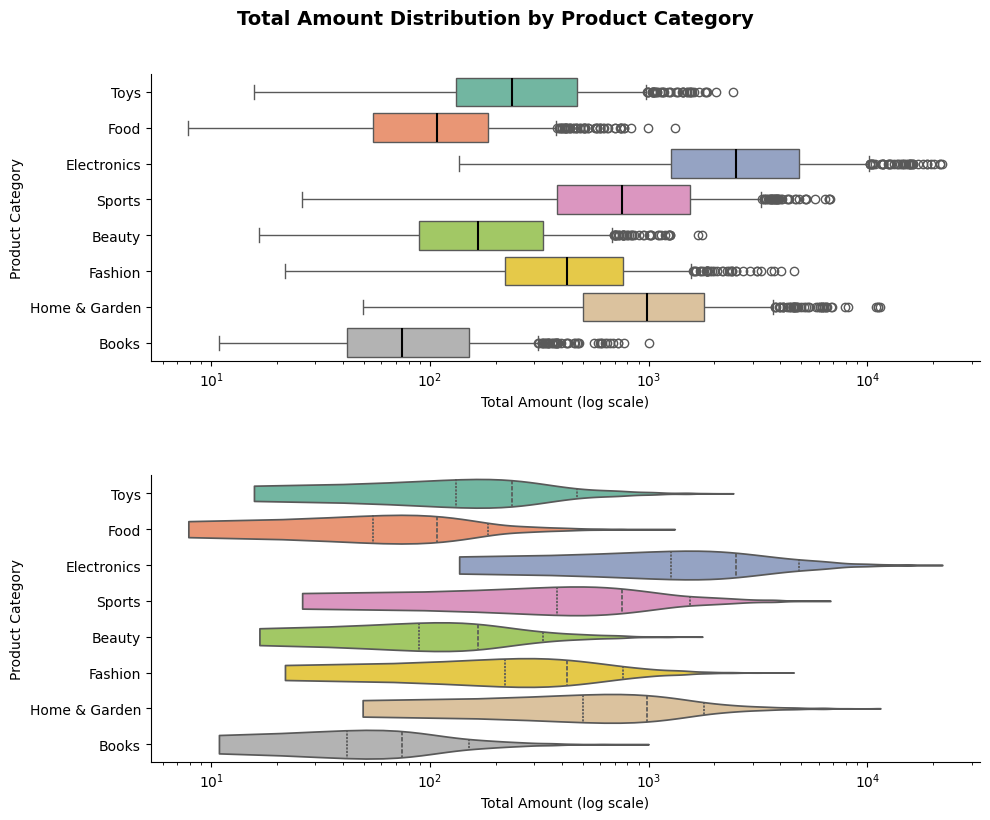

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

sns.boxplot(data=df_purchase_experience,x="Total_Amount",y="Product_Category",hue="Product_Category",palette="Set2",legend=False,medianprops={"color": "black", "linewidth": 1.5},ax=axes[0])
axes[0].set_xlabel("Total Amount (log scale)")
axes[0].set_ylabel("Product Category")
axes[0].set_xscale("log")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

sns.violinplot(data=df_purchase_experience,x="Total_Amount",y="Product_Category",hue="Product_Category",palette="Set2",legend=False,cut=0,inner="quartile",ax=axes[1])
axes[1].set_xlabel("Total Amount (log scale)")
axes[1].set_ylabel("Product Category")
axes[1].set_xscale("log")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle("Total Amount Distribution by Product Category",fontsize=14,fontweight="bold",y=1.02)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()


Order value differs meaningfully across product categories. `Electronics` has the highest overall purchase amounts, while categories such as `Books` and `Food` are concentrated at lower values. A log scale is used because total amount is strongly right-skewed.


#### 4.7.3 Session Duration by Device Type


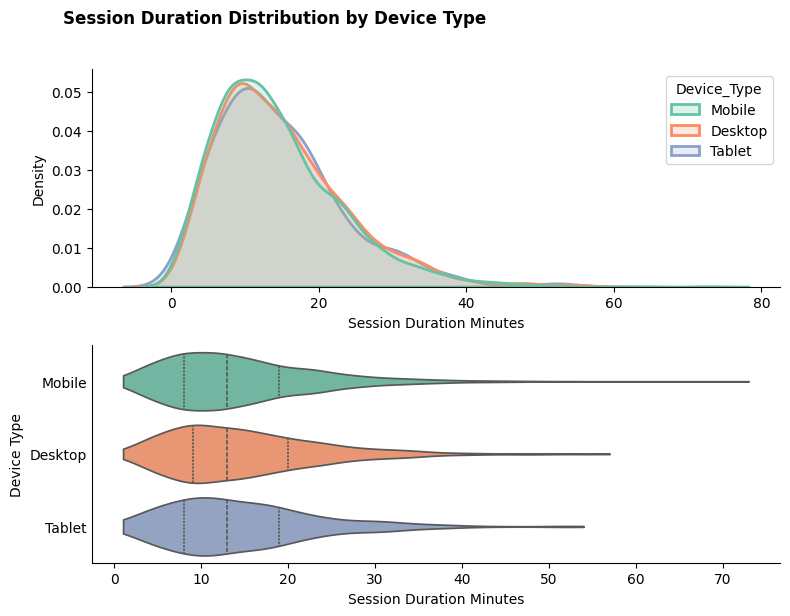

In [44]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
axes = axes.flatten()
# KDE Plot
sns.kdeplot(data=df_purchase_experience,x="Session_Duration_Minutes", hue="Device_Type", common_norm=False, fill=True, alpha=0.2, linewidth=2, palette="Set2", ax=axes[0]) 

axes[0].set_xlabel("Session Duration Minutes")
axes[0].set_ylabel("Density")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
# Violin plot
sns.violinplot(data=df_purchase_experience, x="Session_Duration_Minutes",y="Device_Type", hue="Device_Type", inner="quartile",cut=0,ax=axes[1],palette="Set2")

axes[1].set_xlabel("Session Duration Minutes")
axes[1].set_ylabel("Device Type")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].tick_params(axis="y", length=0)
plt.suptitle("Session Duration Distribution by Device Type", fontsize=12, fontweight="bold", y=1.02, x=0.35)
plt.tight_layout()
plt.show()

Session-duration distributions are very similar across mobile, desktop, and tablet users. The groups share the same general right-skewed shape and overlap heavily, so device type provides little visible separation in session duration.


### 4.8 Dataset 4 Findings

Dataset 4 contains clear right-skew in price, discount, and order-value variables, but the high-end observations remain plausible. Product category is associated with noticeable differences in order value, while delivery-time groups show little separation in customer rating and device type shows little separation in session duration.


## Cross-Dataset Takeaways

The four datasets show very different levels of structure. Dataset 1 contains meaningful variation in sales, profit, categories, and engagement behavior. Dataset 2 is unusually uniform and shows weak separation across the examined groups. Dataset 3 provides the clearest churn-related distribution differences, particularly for customer tenure. Dataset 4 contains strong monetary skew and meaningful differences in order value across product categories.

These findings guide the next stages of analysis by highlighting where stronger relationships are most likely to emerge and where apparent patterns should be treated cautiously.
